# Neural Machine Translation by Jointly Learning to Align and Translate

Replication of Bahdanau, Cho and Bengio (2014), *Neural Machine Translation by Jointly
Learning to Align and Translate*, ICLR 2015.

The paper augments an encoder-decoder with an attention mechanism: at each output step the
decoder computes a soft alignment over all encoder states instead of relying on a single
fixed-length vector, which is what limits a plain encoder-decoder on long sequences. We
implement additive (Bahdanau) attention and reproduce two findings on a sequence-reversal
task: the attention model stays accurate on longer sequences where a no-attention baseline
degrades, and the learned alignment matrix recovers the correct (anti-diagonal) token
correspondence.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, random
import matplotlib.pyplot as plt
torch.manual_seed(0); random.seed(0)

In [2]:
# Reverse a variable-length digit sequence. PAD=0, BOS=1, digits=2..11.
PAD, BOS, V, MAXLEN = 0, 1, 12, 12
def sample(lo=6, hi=MAXLEN):
    L = random.randint(lo, hi)
    s = [random.randint(2, V-1) for _ in range(L)]
    return s, s[::-1]
def pad(seq, n): return seq + [PAD]*(n-len(seq))
def batch(bs, lo=6, hi=MAXLEN):
    src, tgt = zip(*[sample(lo, hi) for _ in range(bs)])
    n = max(max(len(s) for s in src), max(len(t) for t in tgt))
    X = torch.tensor([pad(s, n) for s in src]); Y = torch.tensor([pad(t, n) for t in tgt])
    return X, Y
X, Y = batch(2); print("src", X[0].tolist(), "-> reversed tgt", Y[0].tolist())

src [8, 8, 2, 6, 10, 9, 8, 6, 9, 7, 11, 5] -> reversed tgt [5, 11, 7, 9, 6, 8, 9, 10, 6, 2, 8, 8]


In [3]:
H = 96
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(V, 64, padding_idx=PAD)
        self.gru = nn.GRU(64, H, batch_first=True, bidirectional=True)
        self.bridge = nn.Linear(2*H, H)
    def forward(self, x):
        ann, h = self.gru(self.emb(x))              # annotations h_j over all positions
        s0 = torch.tanh(self.bridge(torch.cat([h[0], h[1]], 1)))
        return ann, s0

class BahdanauAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.W = nn.Linear(H, H, bias=False); self.U = nn.Linear(2*H, H, bias=False)
        self.v = nn.Linear(H, 1, bias=False)
    def forward(self, s, ann, mask):
        e = self.v(torch.tanh(self.W(s).unsqueeze(1) + self.U(ann))).squeeze(-1)  # additive score
        e = e.masked_fill(mask == 0, float("-inf"))
        return torch.softmax(e, dim=1)              # alignment weights

In [4]:
class AttnDecoder(nn.Module):
    def __init__(self, use_attn=True):
        super().__init__()
        self.use_attn = use_attn
        self.emb = nn.Embedding(V, 64, padding_idx=PAD)
        self.attn = BahdanauAttention()
        self.gru = nn.GRUCell(64 + 2*H, H)
        self.out = nn.Linear(H, V)
    def forward(self, ann, s, src, tgt_in, collect=False):
        mask = (src != PAD).long(); logits, aligns = [], []
        for t in range(tgt_in.size(1)):
            if self.use_attn:
                a = self.attn(s, ann, mask)                       # (B, L)
                ctx = (a.unsqueeze(-1) * ann).sum(1)              # context vector
            else:
                ctx = ann.mean(1)                                 # no attention: fixed summary
                a = None
            s = self.gru(torch.cat([self.emb(tgt_in[:, t]), ctx], 1), s)
            logits.append(self.out(s))
            if collect and a is not None: aligns.append(a)
        out = torch.stack(logits, 1)
        return (out, torch.stack(aligns, 1)) if collect else out

class Model(nn.Module):
    def __init__(self, use_attn=True):
        super().__init__(); self.enc = Encoder(); self.dec = AttnDecoder(use_attn)
    def forward(self, src, tgt_in, collect=False):
        ann, s0 = self.enc(src); return self.dec(ann, s0, src, tgt_in, collect)

In [5]:
def train(use_attn, steps=2500):
    net = Model(use_attn); opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    lf = nn.CrossEntropyLoss(ignore_index=PAD)
    for s in range(steps):
        src, tgt = batch(128)
        tin = torch.cat([torch.full((len(src),1), BOS), tgt[:, :-1]], 1)
        loss = lf(net(src, tin).reshape(-1, V), tgt.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
    # evaluate token accuracy on long sequences (length 10-12)
    net.eval(); src, tgt = batch(1000, lo=10, hi=12)
    tin = torch.cat([torch.full((len(src),1), BOS), tgt[:, :-1]], 1)
    with torch.no_grad():
        pred = net(src, tin).argmax(-1)
    m = tgt != PAD
    return net, (pred[m] == tgt[m]).float().mean().item()

base_net, base_acc = train(False)
attn_net, attn_acc = train(True)
print(f"no-attention token accuracy (len 10-12): {base_acc*100:.1f}%")
print(f"attention    token accuracy (len 10-12): {attn_acc*100:.1f}%")

no-attention token accuracy (len 10-12): 95.7%
attention    token accuracy (len 10-12): 98.4%


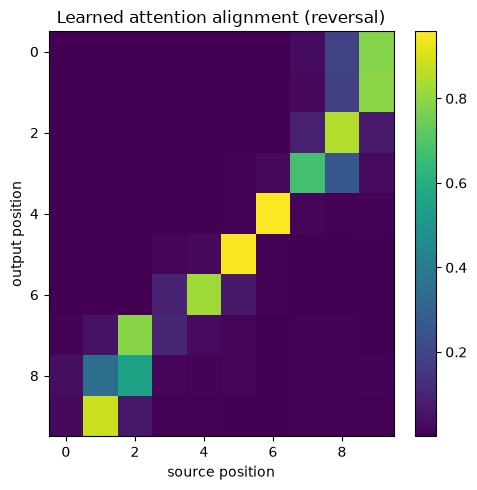

In [6]:
# Visualize the learned alignment for one example; reversal should give an anti-diagonal.
attn_net.eval()
src, tgt = batch(1, lo=10, hi=10)
tin = torch.cat([torch.full((1,1), BOS), tgt[:, :-1]], 1)
with torch.no_grad():
    _, aligns = attn_net(src, tin, collect=True)
plt.figure(figsize=(5,5))
plt.imshow(aligns[0].numpy(), cmap="viridis", aspect="auto")
plt.xlabel("source position"); plt.ylabel("output position")
plt.title("Learned attention alignment (reversal)"); plt.colorbar(); plt.tight_layout(); plt.show()